# Import Modules

In [1]:
from matplotlib.pyplot import *
from numpy             import *
from pandas            import *
from pyatomdb          import *
from seaborn           import *

# Setup Seaborn

In [2]:
set        ()
set_context("notebook")

# Si01 Level

In [3]:
Level            = []
Energy           = []
NL               = []
J                = []
Configuration    = []
Si01_Translation = {}

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si01.en") as file:
    for line in file.readlines():
        line = line.split()
        Level         += [int(line[1])]
        Energy        += [float(line[3])]
        NL            += [int(line[5])]
        J             += [int(line[6])]
        Configuration += [" ".join(line[7:])]

Monaco_Si01_Level = DataFrame({"Level":Level, "Energy":Energy, "NL":NL, "2J":J, "Configuration":Configuration})
Monaco_Si01_Level

,Level,Energy,NL,2J,Configuration
0,0,0.00000,100,1,1*1 1s1 1s+1(1)1
1,1,2004.34588,201,1,2*1 2p1 2p-1(1)1
2,2,2004.40893,200,1,2*1 2s1 2s+1(1)1
3,3,2006.10069,201,3,2*1 2p1 2p+1(3)3
4,4,2673.20015,100,0,1*0 1s0 1s+0(0)0
...,...,...,...,...,...
432,432,2671.88323,4508,17,45*1 1s0 4 + 45l+1(17)17
433,433,2671.88323,4509,17,45*1 1s0 4 + 45m-1(17)17
434,434,2671.88324,4509,19,45*1 1s0 4 + 45m+1(19)19
435,435,2671.88324,4510,19,45*1 1s0 4 + 45n-1(19)19


## Load XSTAR Database

In [4]:
Xstar_Si01_Level = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si01_Level.tsv",sep="\t")
Xstar_Si01_Level.drop(columns=["Unnamed: 0", "Z", "Ion", "Electron", "Potential"], inplace=True)
Xstar_Si01_Level.head()

,Level,N,L,2S+1,2J+1,Energy,Configuration
0,1,1,0,2,2,0.000,1s1.2S_1/2
1,2,2,1,2,2,2004.328,1s0.2p1.2P_1/2
2,3,2,1,2,4,2006.082,1s0.2p1.2P_3/2
3,4,2,0,2,2,2004.393,1s0.2s1.2S_1/2
4,5,3,1,2,2,2376.108,1s0.3p1.2P_1/2


## Match Database

In [5]:
Si01_Level_Index  = []
Si01_Level_Energy = []
Si01_Transition   = {}

for i in range(10):
    for j in range(len(Xstar_Si01_Level.index)-1):
        if Monaco_Si01_Level["NL"][i]==(100*Xstar_Si01_Level["N"][j]+Xstar_Si01_Level["L"][j]) and Monaco_Si01_Level["2J"][i]==Xstar_Si01_Level["2J+1"][j]-1:
            Si01_Level_Index  += [Monaco_Si01_Level["Level"][i]]
            Si01_Level_Energy += [ Xstar_Si01_Level["Energy"][j]-Monaco_Si01_Level["Energy"][i]]
            Si01_Transition[Xstar_Si01_Level["Level"][j]] = Monaco_Si01_Level["Level"][i]

## Plot Energy

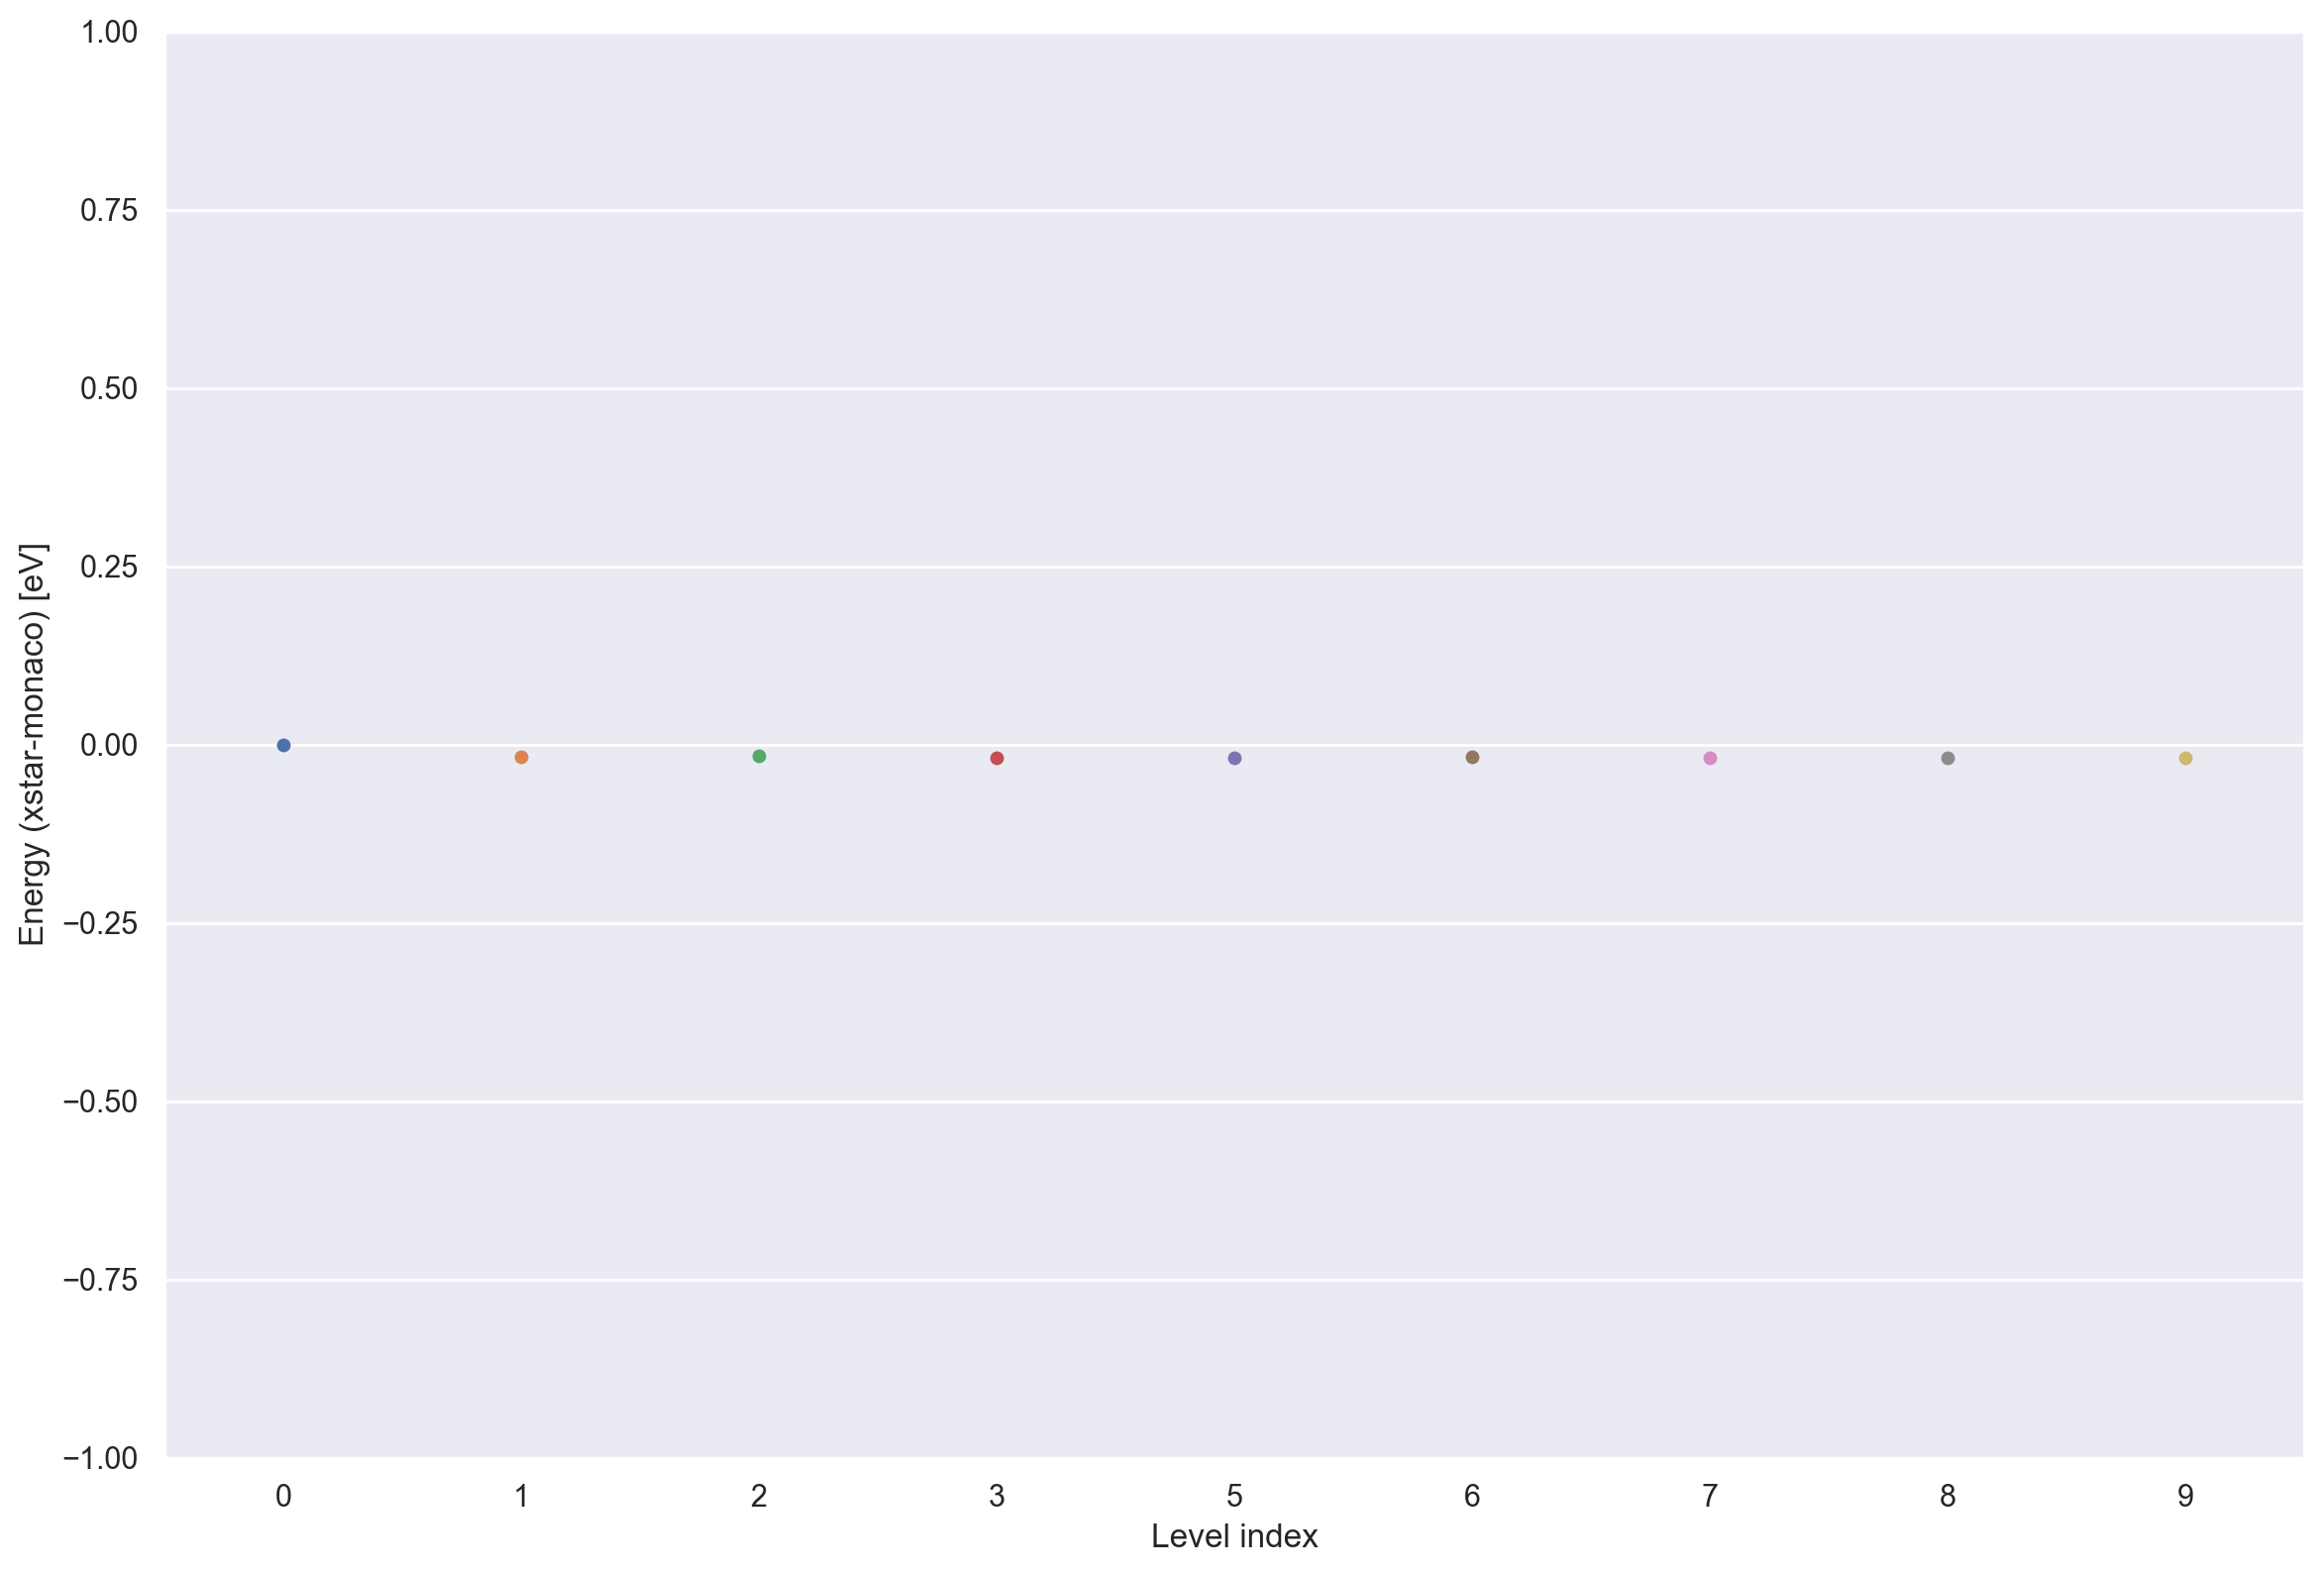

In [6]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+1,-1e+0,+1e+0])
swarmplot      (x=Si01_Level_Index, y=Si01_Level_Energy)
xlabel         ("Level index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/01.png")

# Si02 Level

In [7]:
Level            = []
Energy           = []
NL               = []
J                = []
Configuration    = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si02.en") as file:
    for line in file.readlines():
        line = line.split()
        Level         += [int(line[1])]
        Energy        += [float(line[3])]
        NL            += [int(line[5])]
        J             += [int(line[6])]
        Configuration += [" ".join(line[7:])]

Monaco_Si02_Level = DataFrame({"Level":Level, "Energy":Energy, "NL":NL, "2J":J, "Configuration":Configuration})
Monaco_Si02_Level

,Level,Energy,NL,2J,Configuration
0,0,0.00000,100,0,1*2 1s2 1s+2(0)0
1,1,1839.43511,200,2,1*1 2*1 1s1 2s1 1s+1(1)1 2s+1(1)2
2,2,1853.54893,201,0,1*1 2*1 1s1 2p1 1s+1(1)1 2p-1(1)0
3,3,1853.77319,201,2,1*1 2*1 1s1 2p1 1s+1(1)1 2p-1(1)2
4,4,1854.64932,201,4,1*1 2*1 1s1 2p1 1s+1(1)1 2p+1(3)4
...,...,...,...,...,...
4296,4296,4813.33881,4506,10,3*1 45*1 3d1 15 + 45i+1(13)10
4297,4297,4813.33864,4506,12,3*1 45*1 3d1 15 + 45i+1(13)12
4298,4298,4813.33857,4506,14,3*1 45*1 3d1 15 + 45i+1(13)14
4299,4299,4813.33861,4506,16,3*1 45*1 3d1 15 + 45i+1(13)16


## Load XSTAR Database

In [8]:
Xstar_Si02_Level = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si02_Level.tsv",sep="\t")
Xstar_Si02_Level.drop(columns=["Unnamed: 0", "Z", "Ion", "Electron", "Potential"], inplace=True)
Xstar_Si02_Level.head()

,Level,N,L,2S+1,2J+1,Energy,Configuration
0,1,1,0,1,1,0.000,1s2.1S_0
1,2,2,0,3,3,1839.423,1s1.2s1.3S_1
2,3,2,1,3,1,1853.535,1s1.2p1.3P_0
3,4,2,1,3,3,1853.756,1s1.2p1.3P_1
4,5,2,1,3,5,1854.642,1s1.2p1.3P_2


## Match Database

In [9]:
Si02_Level_Index  = []
Si02_Level_Energy = []
Si02_Transition   = {}

for i in range(7):
    for j in range(6):
        if Monaco_Si02_Level["NL"][i]==(100*Xstar_Si02_Level["N"][j]+Xstar_Si02_Level["L"][j]) and Monaco_Si02_Level["2J"][i]==Xstar_Si02_Level["2J+1"][j]-1:
            Si02_Level_Index                             += [Monaco_Si02_Level["Level"][i]]
            Si02_Level_Energy                            += [ Xstar_Si02_Level["Energy"][j]-Monaco_Si02_Level["Energy"][i]]
            Si02_Transition[Xstar_Si02_Level["Level"][j]] = Monaco_Si02_Level["Level"][i]

## Plot Energy

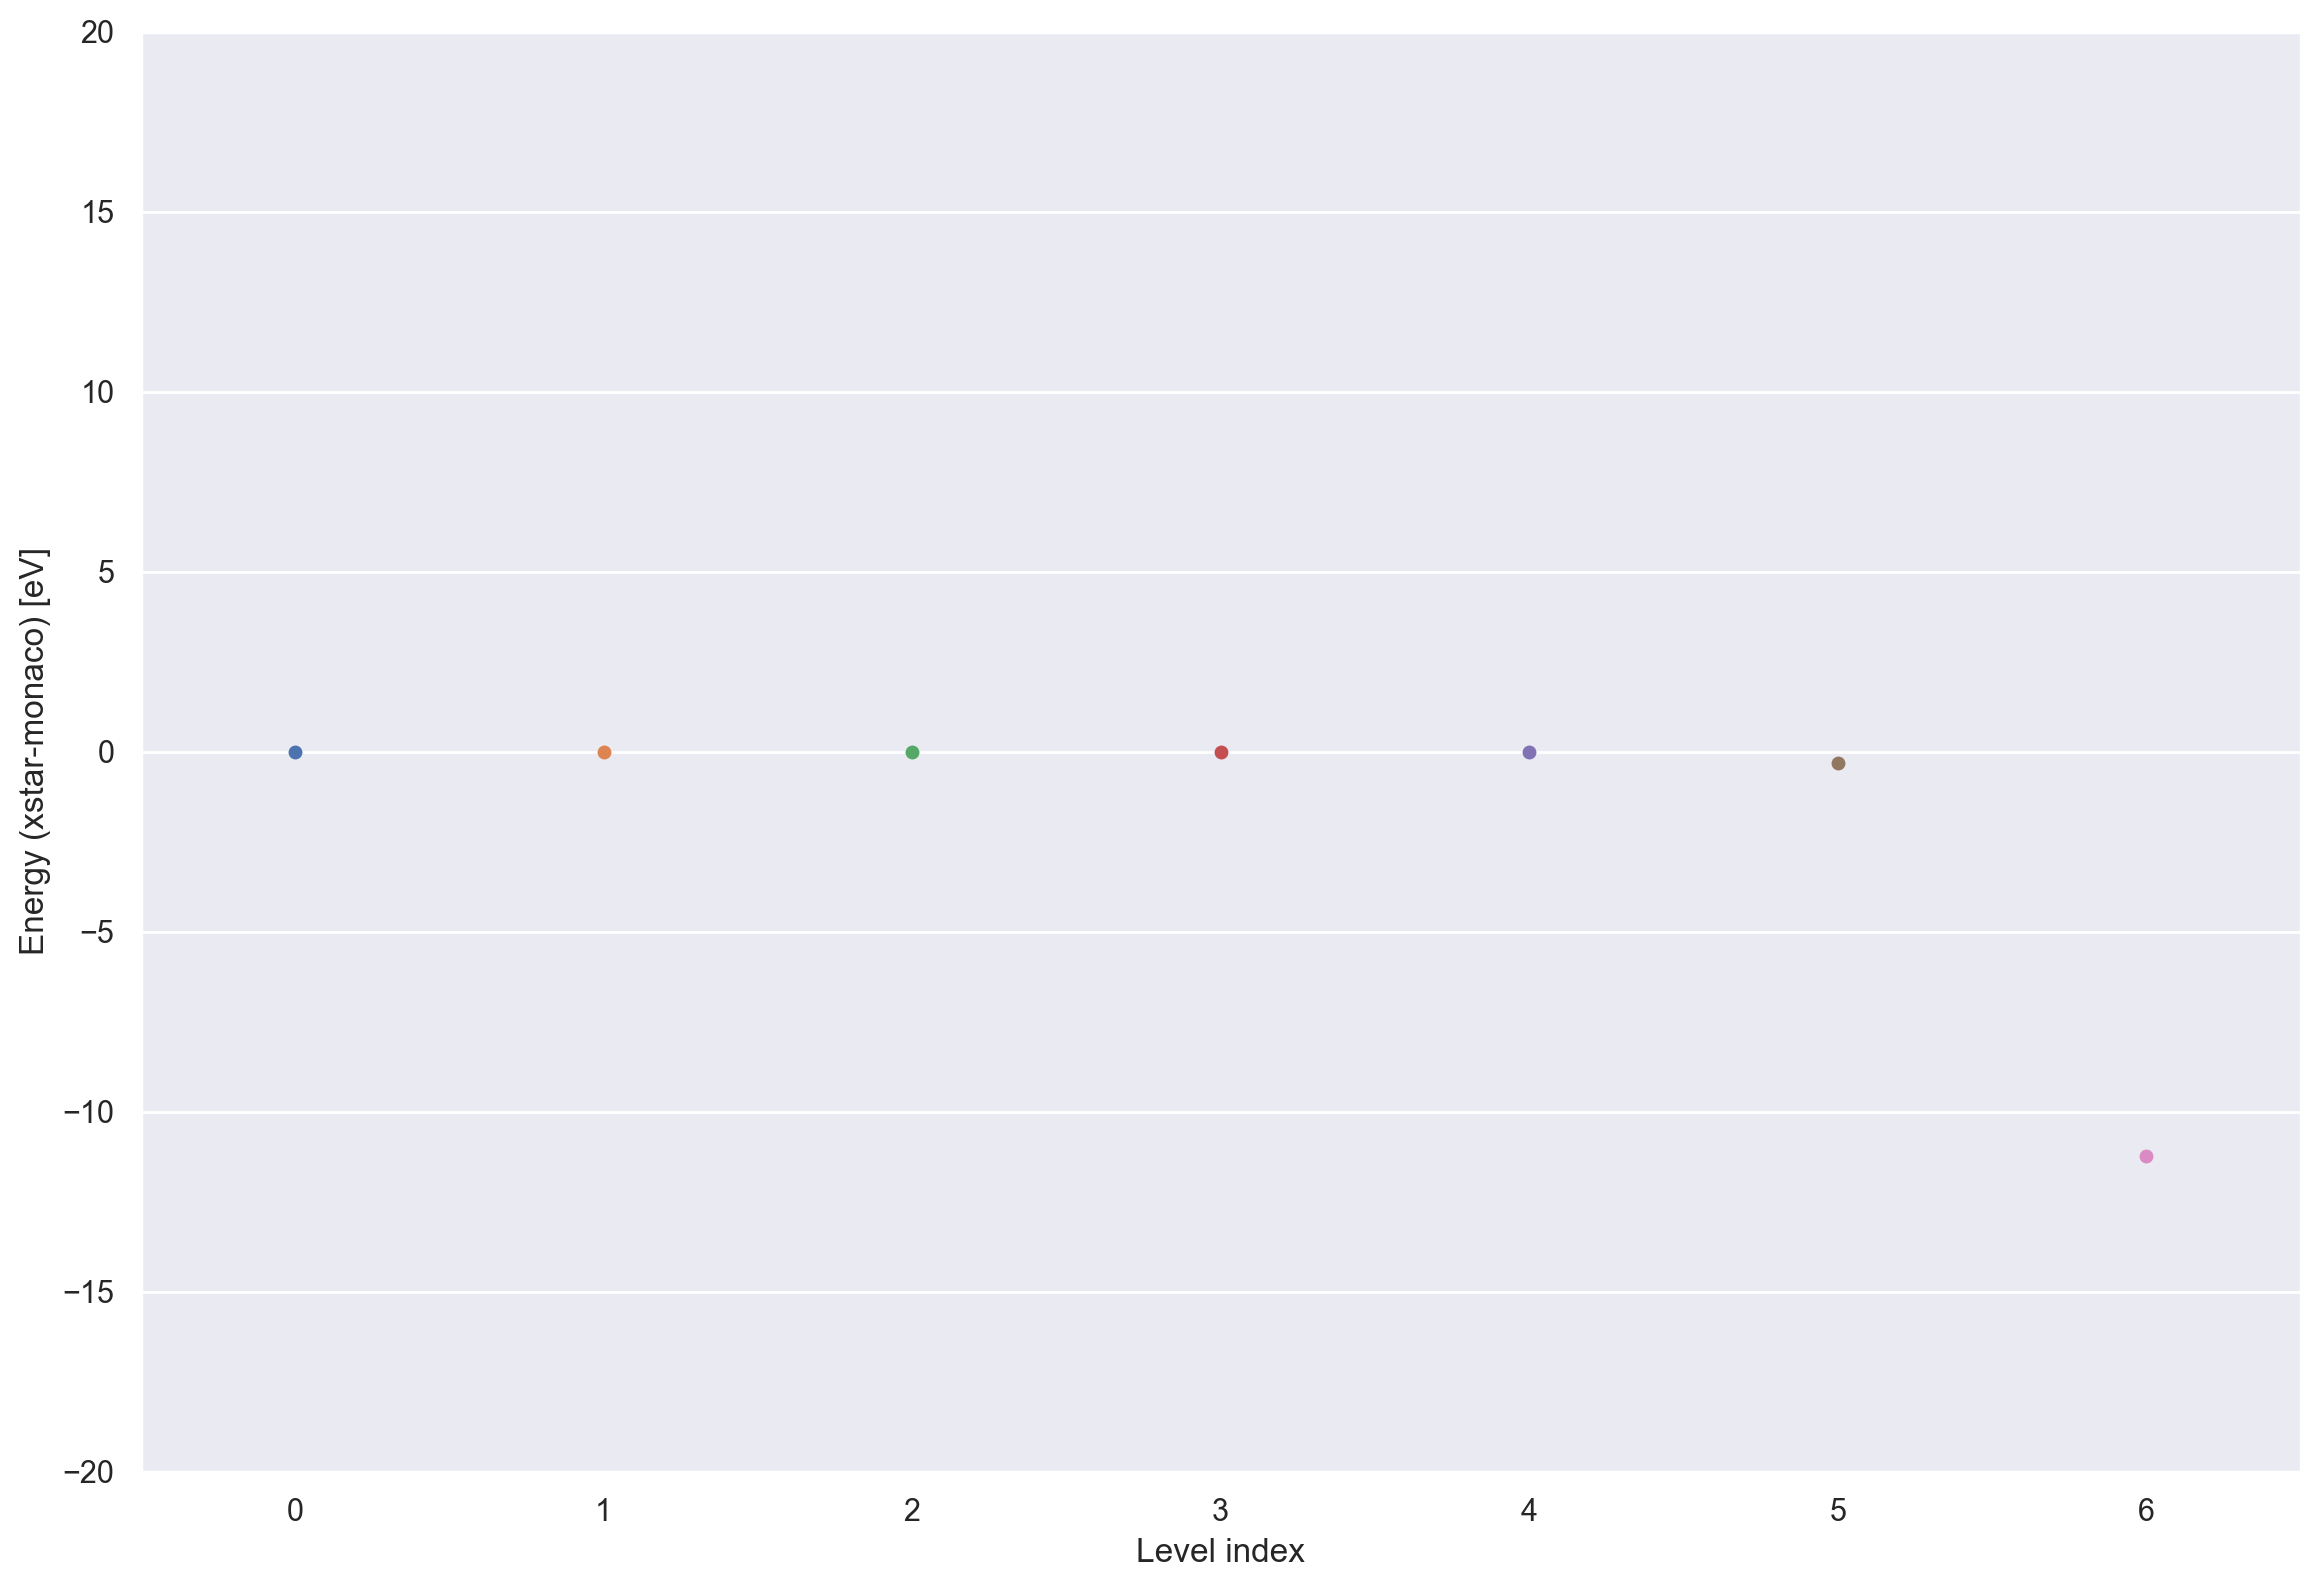

In [10]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+1,-2e+1,+2e+1])
swarmplot      (x=Si02_Level_Index, y=Si02_Level_Energy)
xlabel         ("Level index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/02.png")

# Si01 Transition

In [11]:
Initial_Level = []
Final_Level   = []
Energy        = []
Rate          = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si01.tr") as file:
    for line in file.readlines():
        line = line.split()
        Initial_Level += [int(line[0])]
        Final_Level   += [int(line[2])]
        Energy        += [float(line[4])]
        Rate          += [float(line[6])]

Monaco_Si01_Transition = DataFrame({"Initial Level":Initial_Level, "Final Level":Final_Level, "Energy":Energy, "Rate":Rate})
Monaco_Si01_Transition

,Initial Level,Final Level,Energy,Rate
0,1,0,2004.346000,2.405954e+13
1,2,0,2004.409000,7.298233e+05
2,2,1,0.063051,1.212951e+01
3,3,0,2006.101000,2.411383e+13
4,3,1,1.754814,2.545883e+01
...,...,...,...,...
5577,434,81,31.605940,8.189864e+05
5578,434,98,25.350750,1.798769e+06
5579,435,99,25.350750,3.983457e+05
5580,435,100,25.350440,2.104646e+03


## Load XSTAR Database

In [12]:
Xstar_Si01_Transition = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si01_Transition01.tsv",sep="\t")
Xstar_Si01_Transition = Xstar_Si01_Transition.drop(columns=["Unnamed: 0", "Z", "Ion", "Strength"])

for n in range(133):
    if Xstar_Si01_Transition["Initial Level"][n] in Si01_Transition.keys() and Xstar_Si01_Transition["Final Level"][n] in Si01_Transition.keys() and 1000<Xstar_Si01_Transition["Energy"][n]:
        Xstar_Si01_Transition["Initial Level"][n] = Si01_Transition[Xstar_Si01_Transition["Initial Level"][n]]
        Xstar_Si01_Transition["Final Level"][n]   = Si01_Transition[Xstar_Si01_Transition["Final Level"][n]]
    else:
        Xstar_Si01_Transition.drop(index=n, inplace=True)

Xstar_Si01_Transition = Xstar_Si01_Transition.reset_index().drop(columns="index")
Xstar_Si01_Transition

,Initial Level,Final Level,Energy,Rate
0,1,0,2004.259,2.406770e+13
1,3,0,2006.014,2.406770e+13
2,5,0,2376.027,6.425310e+12
3,8,0,2376.547,6.425310e+12


## Match Database

In [13]:
Si01_Transition_Index    = []
Si01_Transition_Energy   = []
Si01_Transition_Rate     = []

for i in range(len(Monaco_Si01_Transition.index)):
    for j in range(len(Xstar_Si01_Transition.index)):
        if Monaco_Si01_Transition["Initial Level"][i]==Xstar_Si01_Transition["Initial Level"][j] and Monaco_Si01_Transition["Final Level"][i]==Xstar_Si01_Transition["Final Level"][j]:
            Si01_Transition_Index    += ["{0:04d}".format(100*Monaco_Si01_Transition["Initial Level"][i]+Monaco_Si01_Transition["Final Level"][i])]
            Si01_Transition_Energy   += [Xstar_Si01_Transition["Energy"][j]-Monaco_Si01_Transition["Energy"][i]]
            Si01_Transition_Rate     += [log10(Xstar_Si01_Transition["Rate"][j])-log10(Monaco_Si01_Transition["Rate"][i])]

## Plot Energy

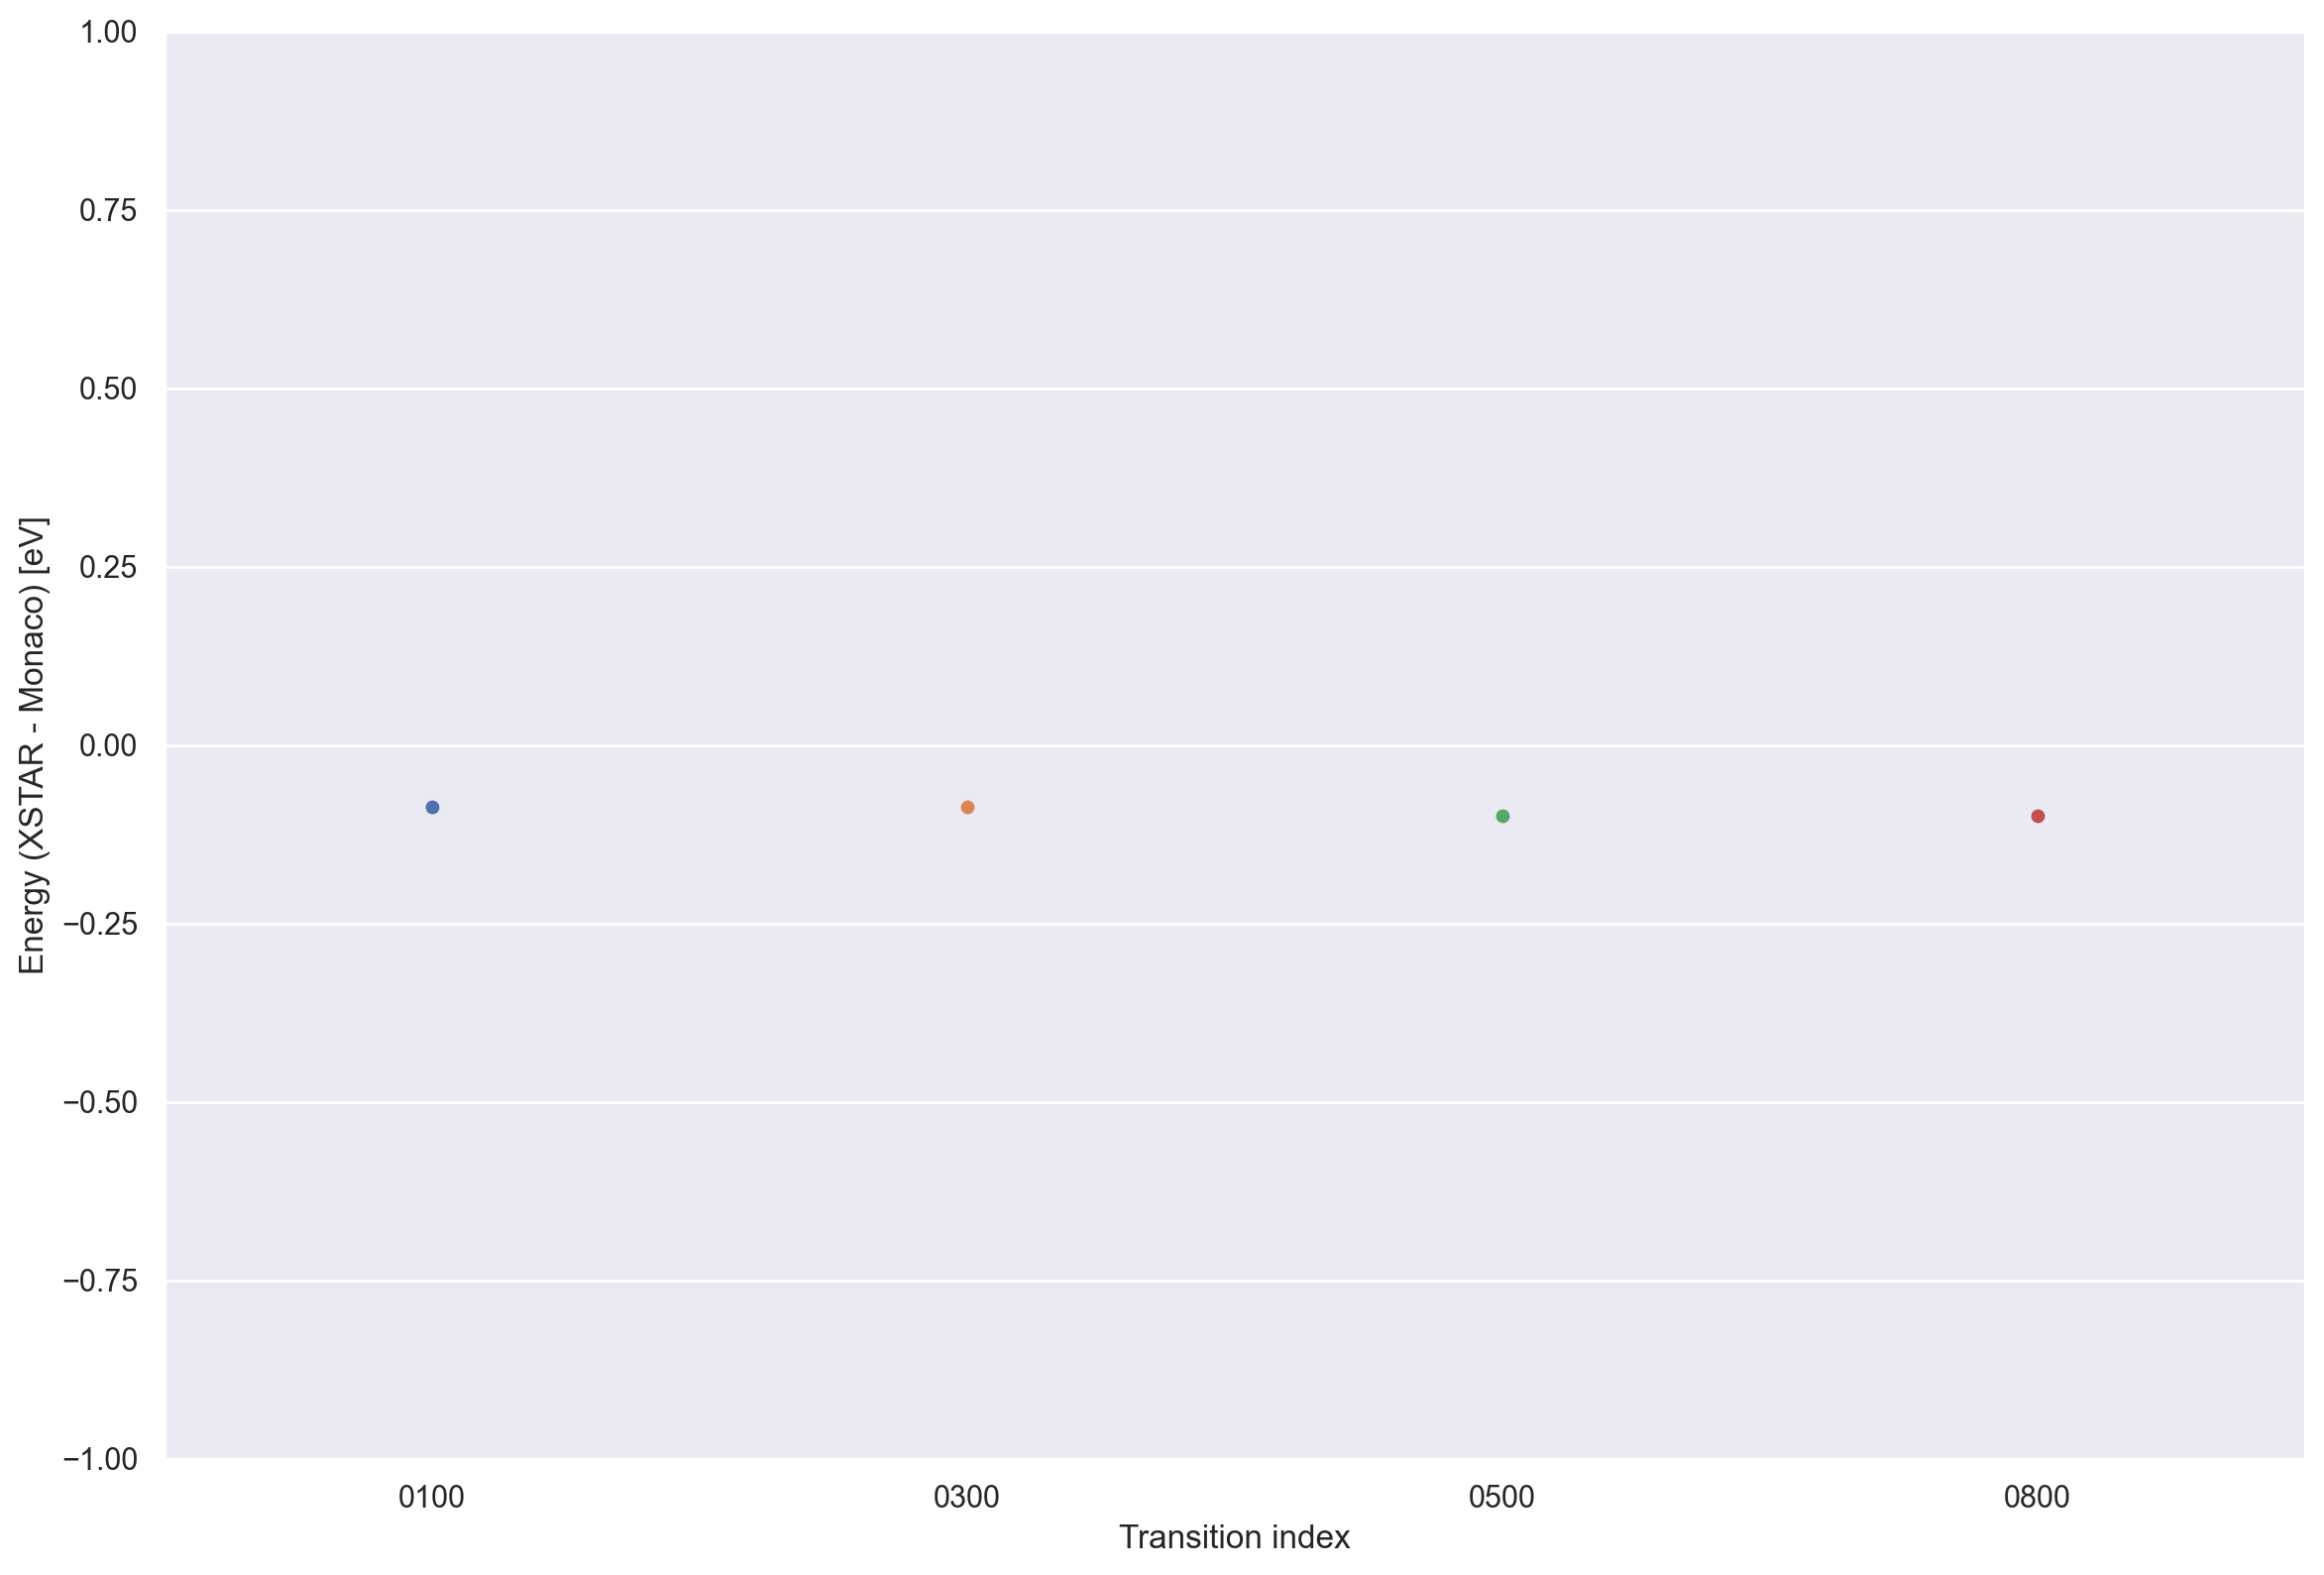

In [14]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-1e+0,+1e+0])
swarmplot      (x=Si01_Transition_Index, y=Si01_Transition_Energy)
xlabel         ("Transition index")
ylabel         ("Energy (XSTAR - Monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/03.png")

## Plot Rate

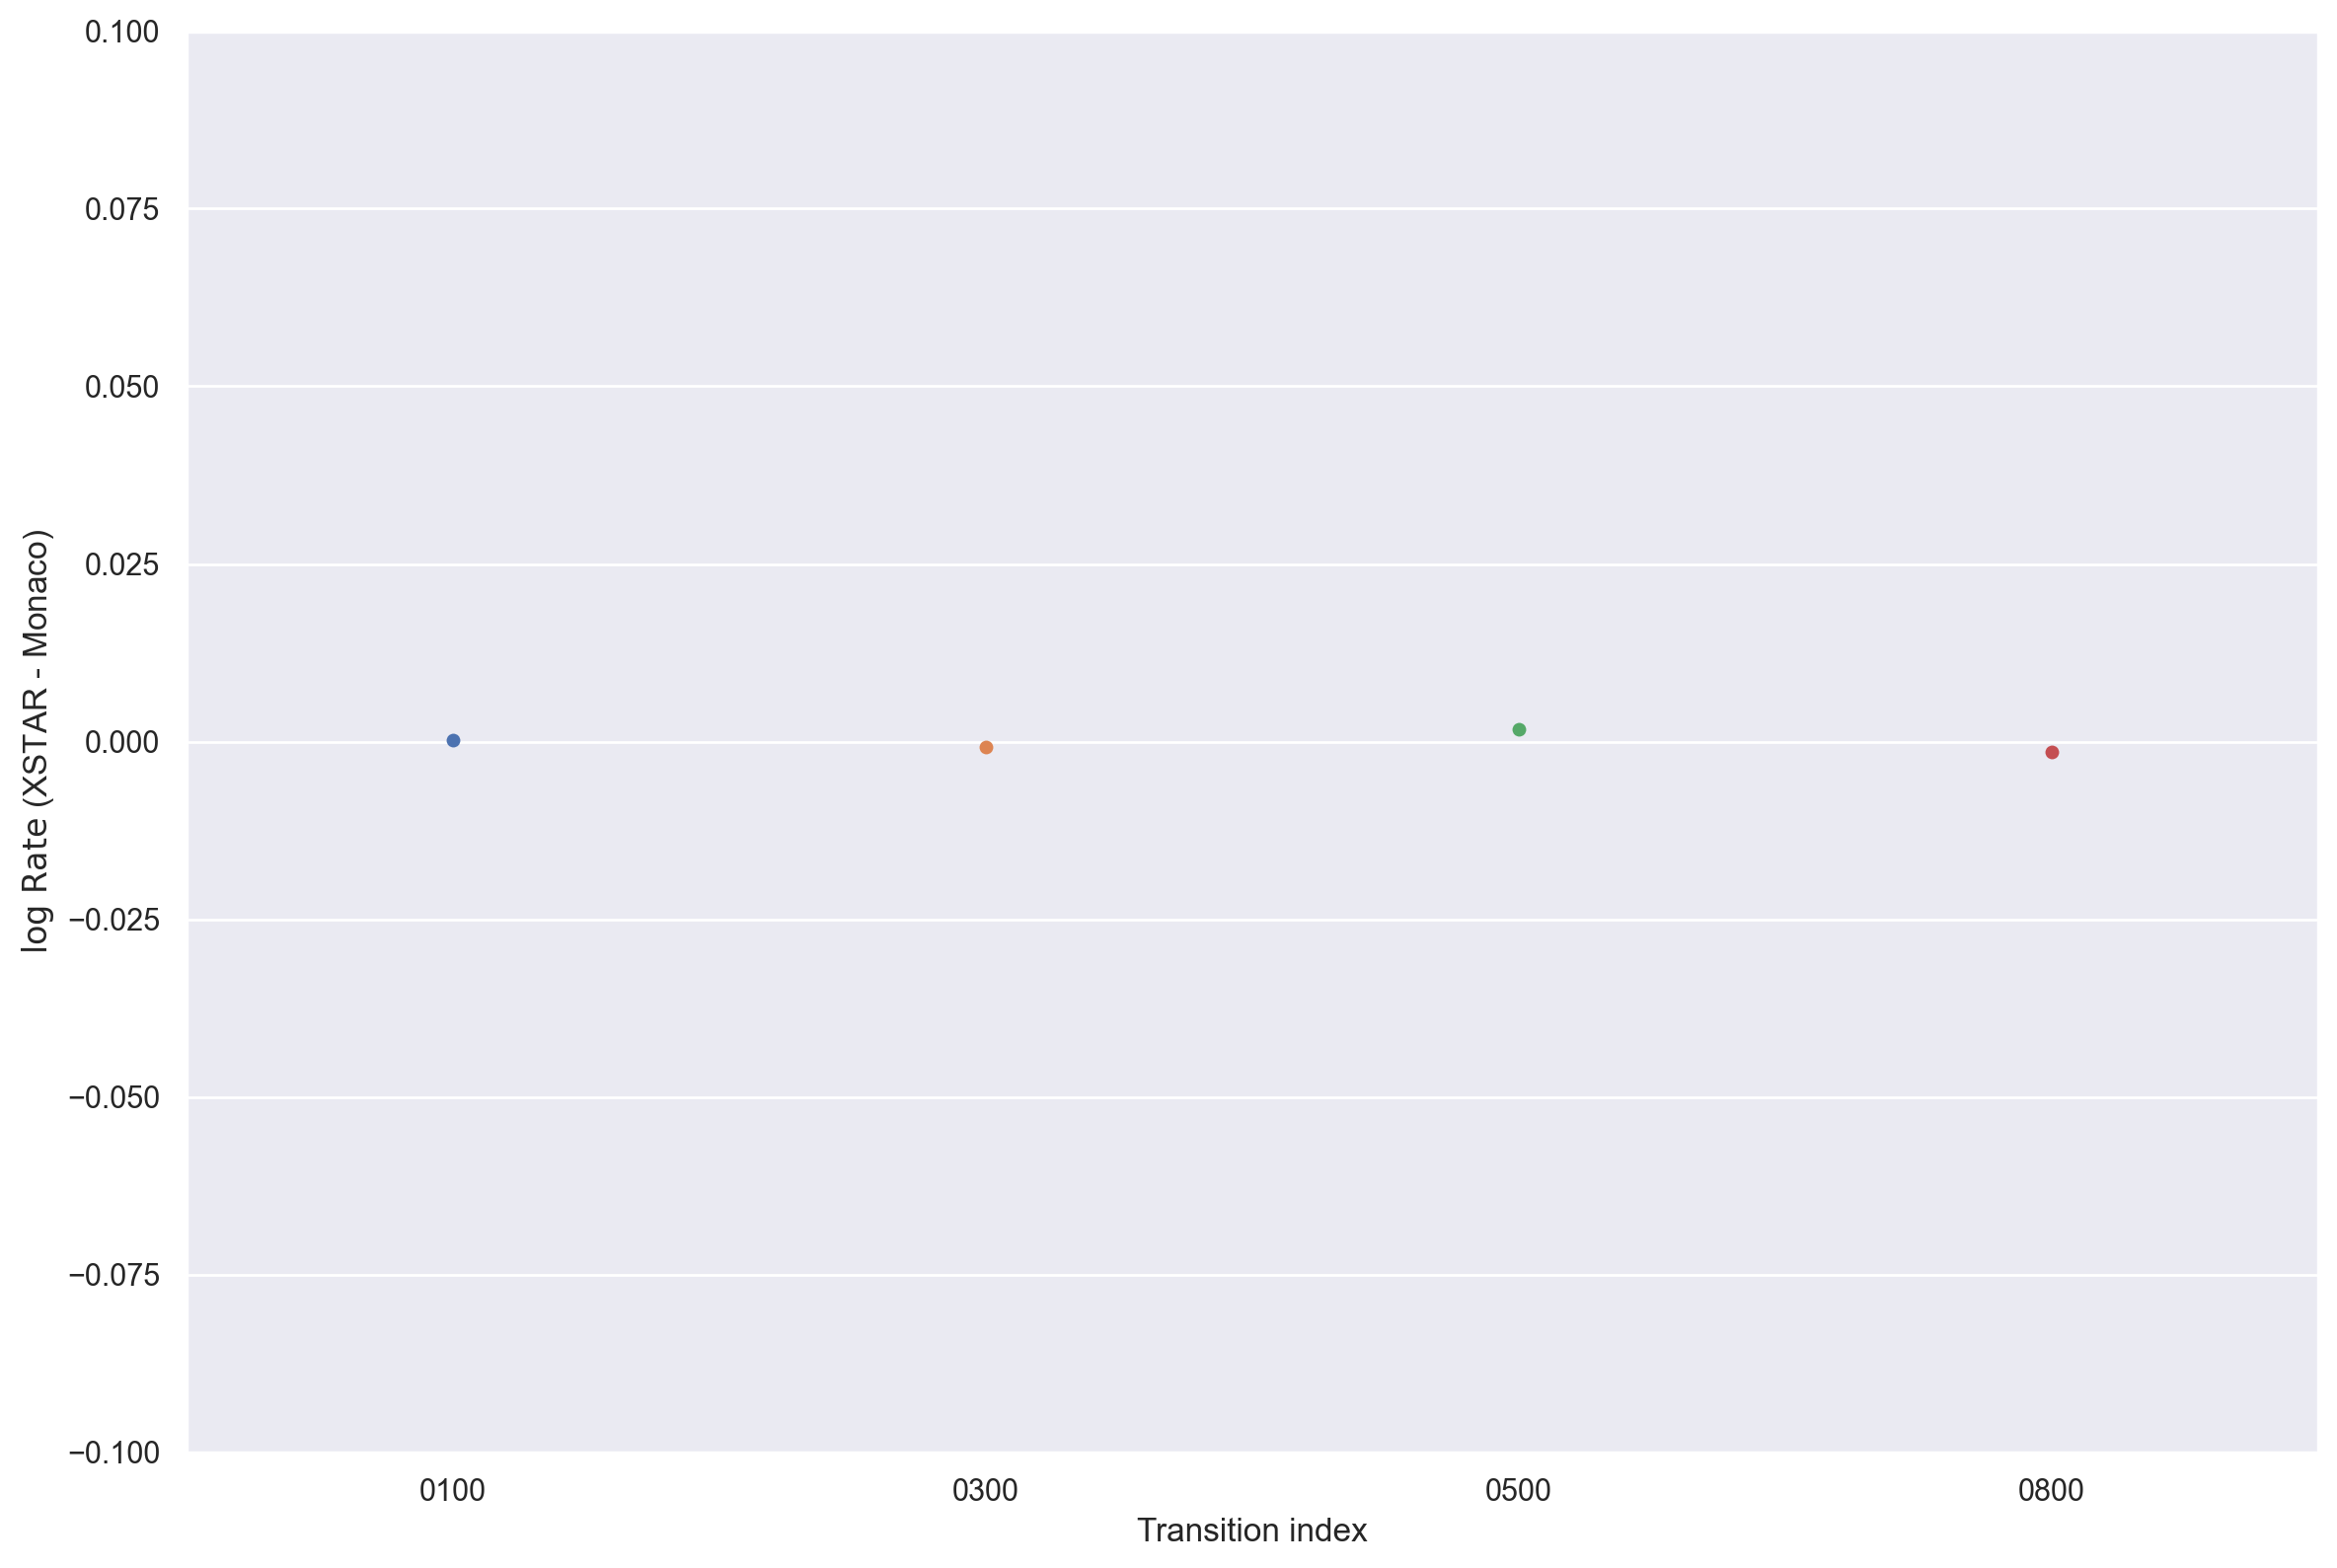

In [15]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-1e-1,+1e-1])
swarmplot      (x=Si01_Transition_Index, y=Si01_Transition_Rate)
xlabel         ("Transition index")
ylabel         ("$\log \ \mathrm{Rate}$ (XSTAR - Monaco)")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/04.png")

# Si02 Transition

In [16]:
Initial_Level = []
Final_Level   = []
Energy        = []
Rate          = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si02.tr") as file:
    for line in file.readlines():
        line = line.split()
        if 1000<float(line[4]):
            Initial_Level += [int(line[0])]
            Final_Level   += [int(line[2])]
            Energy        += [float(line[4])]
            Rate          += [float(line[6])]

Monaco_Si02_Transition = DataFrame({"Initial Level":Initial_Level, "Final Level":Final_Level, "Energy":Energy, "Rate":Rate})
Monaco_Si02_Transition

,Initial Level,Final Level,Energy,Rate
0,1,0,1839.435,3.268689e+05
1,3,0,1853.773,1.366361e+11
2,4,0,1854.649,3.782172e+07
3,6,0,1864.994,3.879524e+13
4,16,0,2175.321,1.432612e+05
...,...,...,...,...
11544,4292,863,2376.671,1.831514e+12
11545,4293,861,2376.671,1.744415e+11
11546,4293,862,2376.671,2.519902e+12
11547,4293,863,2376.671,4.094842e+12


## Load XSTAR Database

In [17]:
Xstar_Si02_Transition = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si02_Transition01.tsv",sep="\t")
Xstar_Si02_Transition = Xstar_Si02_Transition.drop(columns=["Unnamed: 0", "Z", "Ion", "Strength"])

for n in range(212):
    if Xstar_Si02_Transition["Initial Level"][n] in Si02_Transition.keys() and Xstar_Si02_Transition["Final Level"][n] in Si02_Transition.keys() and 1000<Xstar_Si02_Transition["Energy"][n]:
        Xstar_Si02_Transition["Initial Level"][n] = Si02_Transition[Xstar_Si02_Transition["Initial Level"][n]]
        Xstar_Si02_Transition["Final Level"][n]   = Si02_Transition[Xstar_Si02_Transition["Final Level"][n]]
    else:
        Xstar_Si02_Transition.drop(index=n, inplace=True)

Xstar_Si02_Transition = Xstar_Si02_Transition.reset_index().drop(columns="index")
Xstar_Si02_Transition

,Initial Level,Final Level,Energy,Rate
0,1,0,1839.360,360000.0
1,2,0,1853.471,137150000.0
2,6,0,1853.693,137150000.0
3,4,0,1854.579,137150000.0


## Match Database

In [18]:
Si02_Transition_Index    = []
Si02_Transition_Energy   = []
Si02_Transition_Rate     = []

for i in range(len(Monaco_Si02_Transition.index)):
    for j in range(len(Xstar_Si02_Transition.index)):
        if Monaco_Si02_Transition["Initial Level"][i]==Xstar_Si02_Transition["Initial Level"][j] and Monaco_Si02_Transition["Final Level"][i]==Xstar_Si02_Transition["Final Level"][j]:
            Si02_Transition_Index    += ["{0:04d}".format(100*Monaco_Si02_Transition["Initial Level"][i]+Monaco_Si02_Transition["Final Level"][i])]
            Si02_Transition_Energy   += [Xstar_Si02_Transition["Energy"][j]-Monaco_Si02_Transition["Energy"][i]]
            Si02_Transition_Rate     += [log10(Xstar_Si02_Transition["Rate"][j])-log10(Monaco_Si02_Transition["Rate"][i])]

## Plot Transition Energy

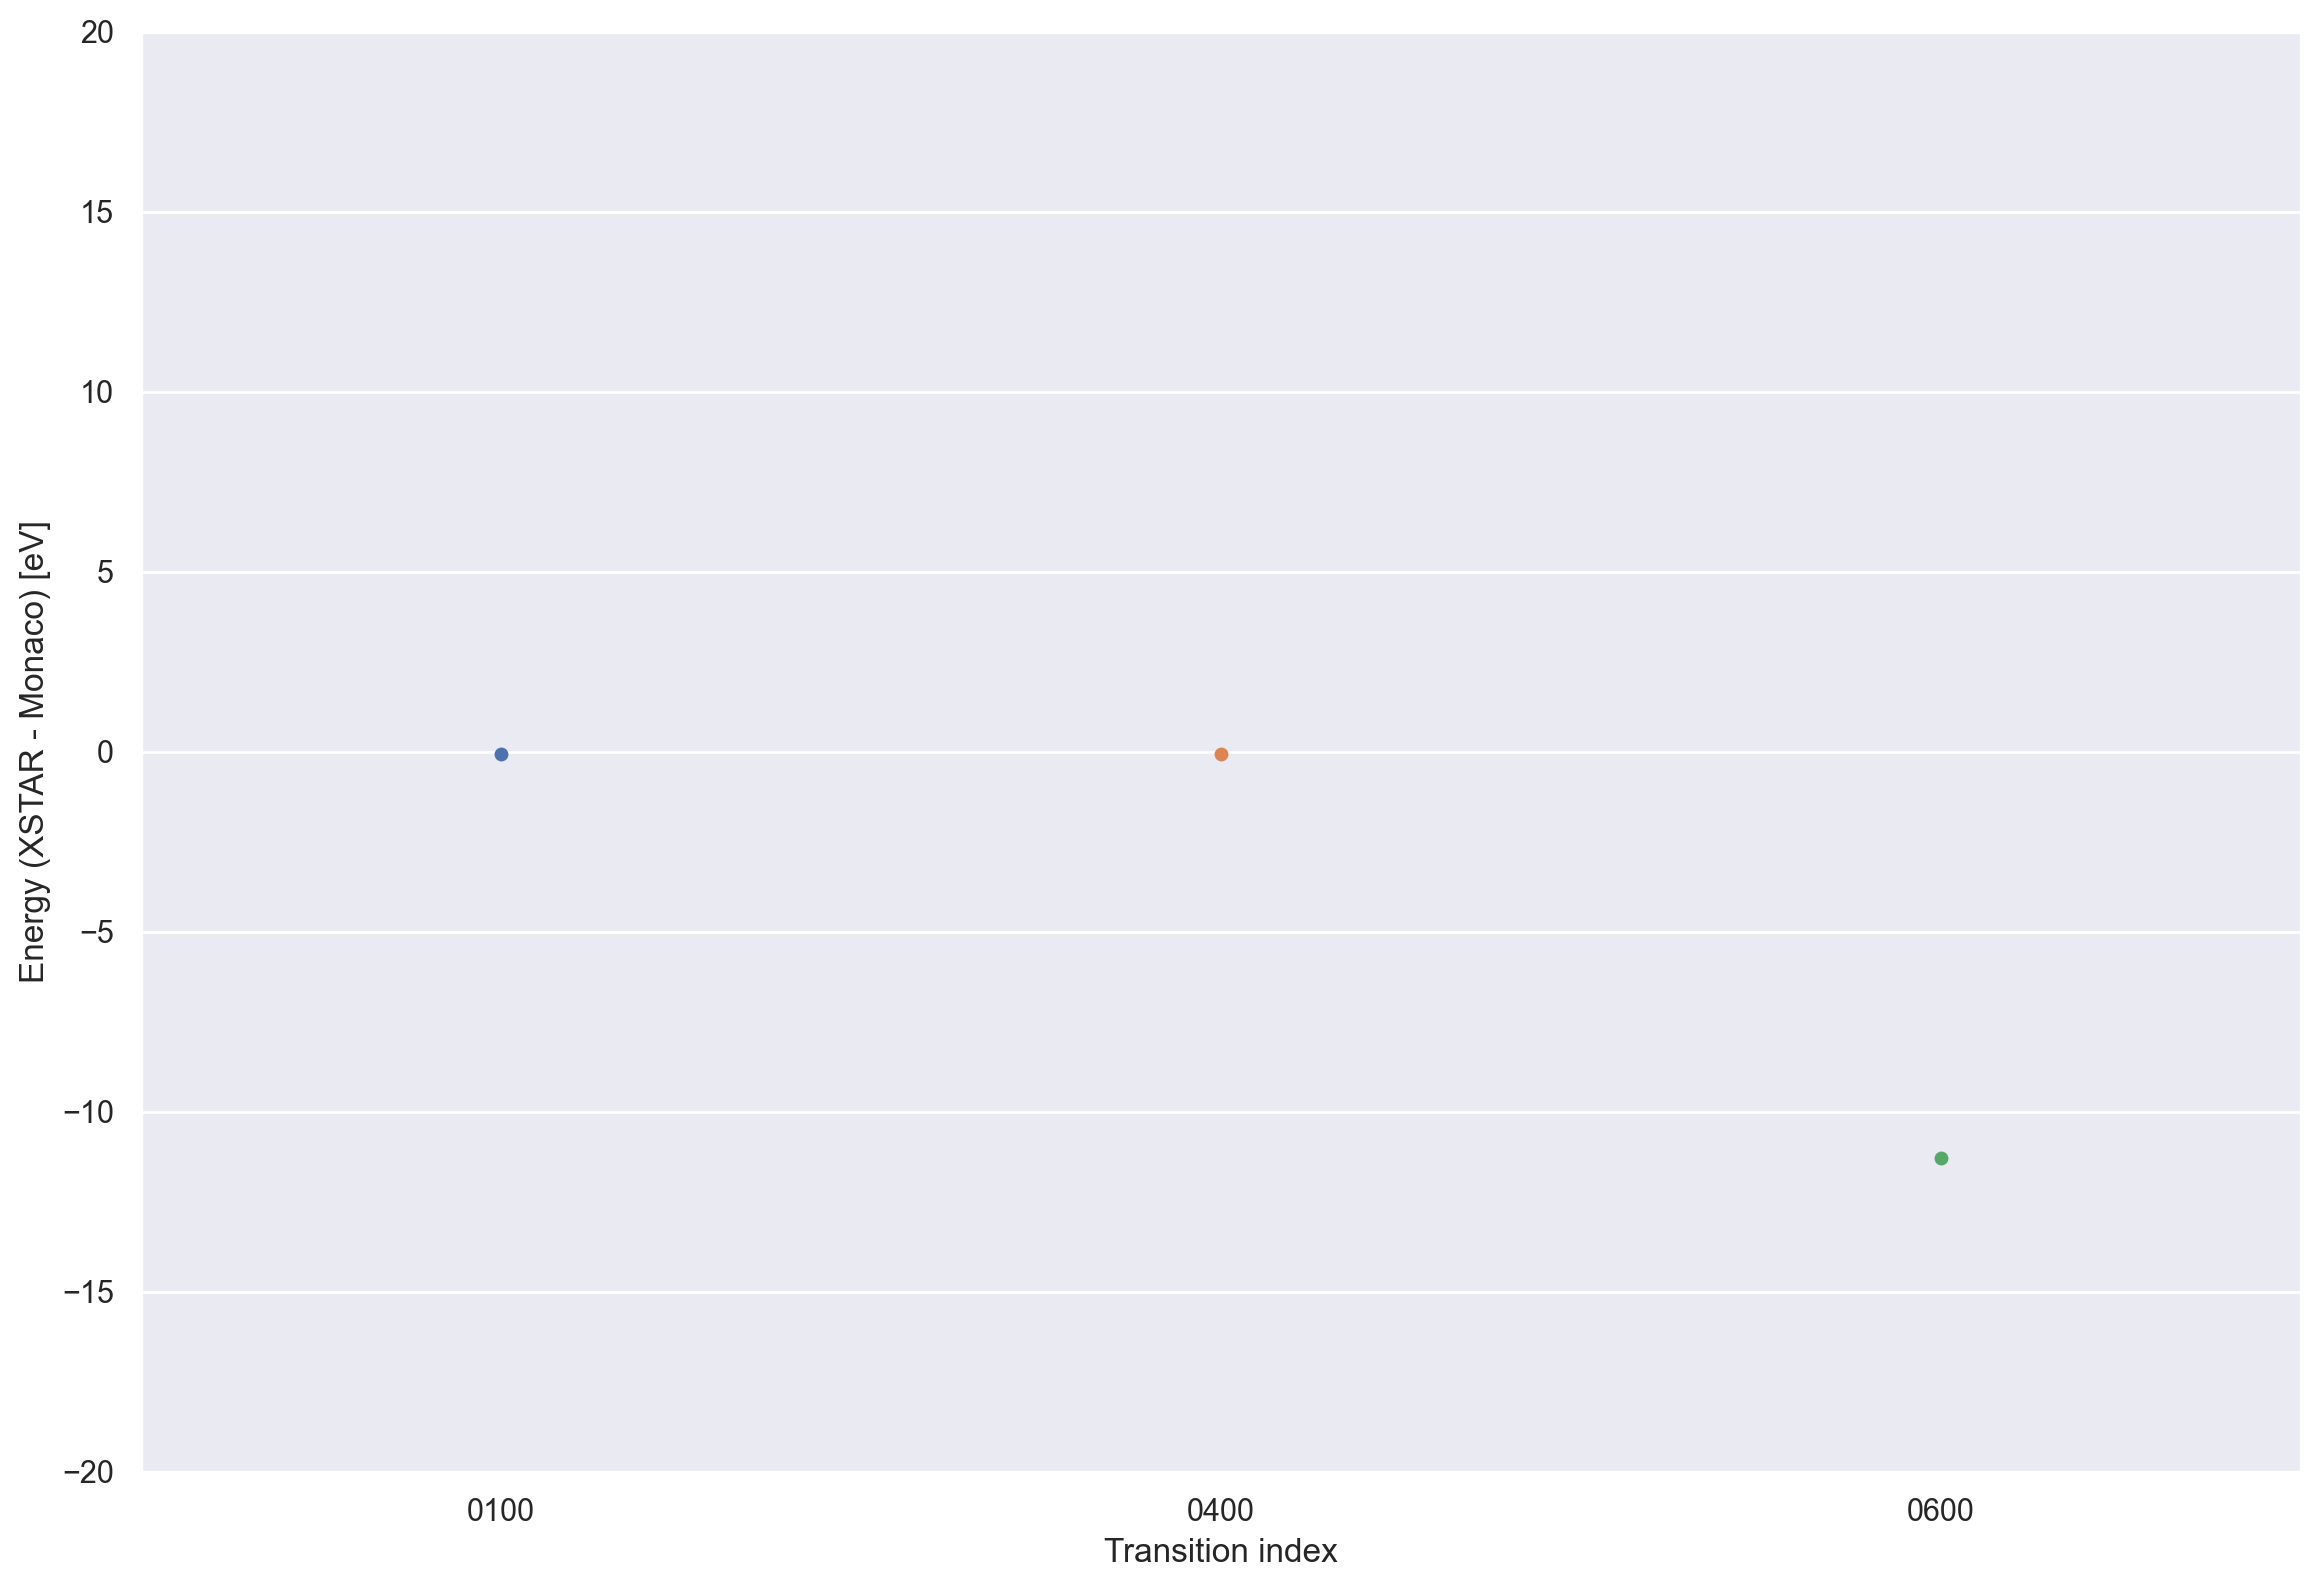

In [19]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-2e+1,+2e+1])
swarmplot      (x=Si02_Transition_Index, y=Si02_Transition_Energy)
xlabel         ("Transition index")
ylabel         ("Energy (XSTAR - Monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/05.png")

## Plot Transition Rate

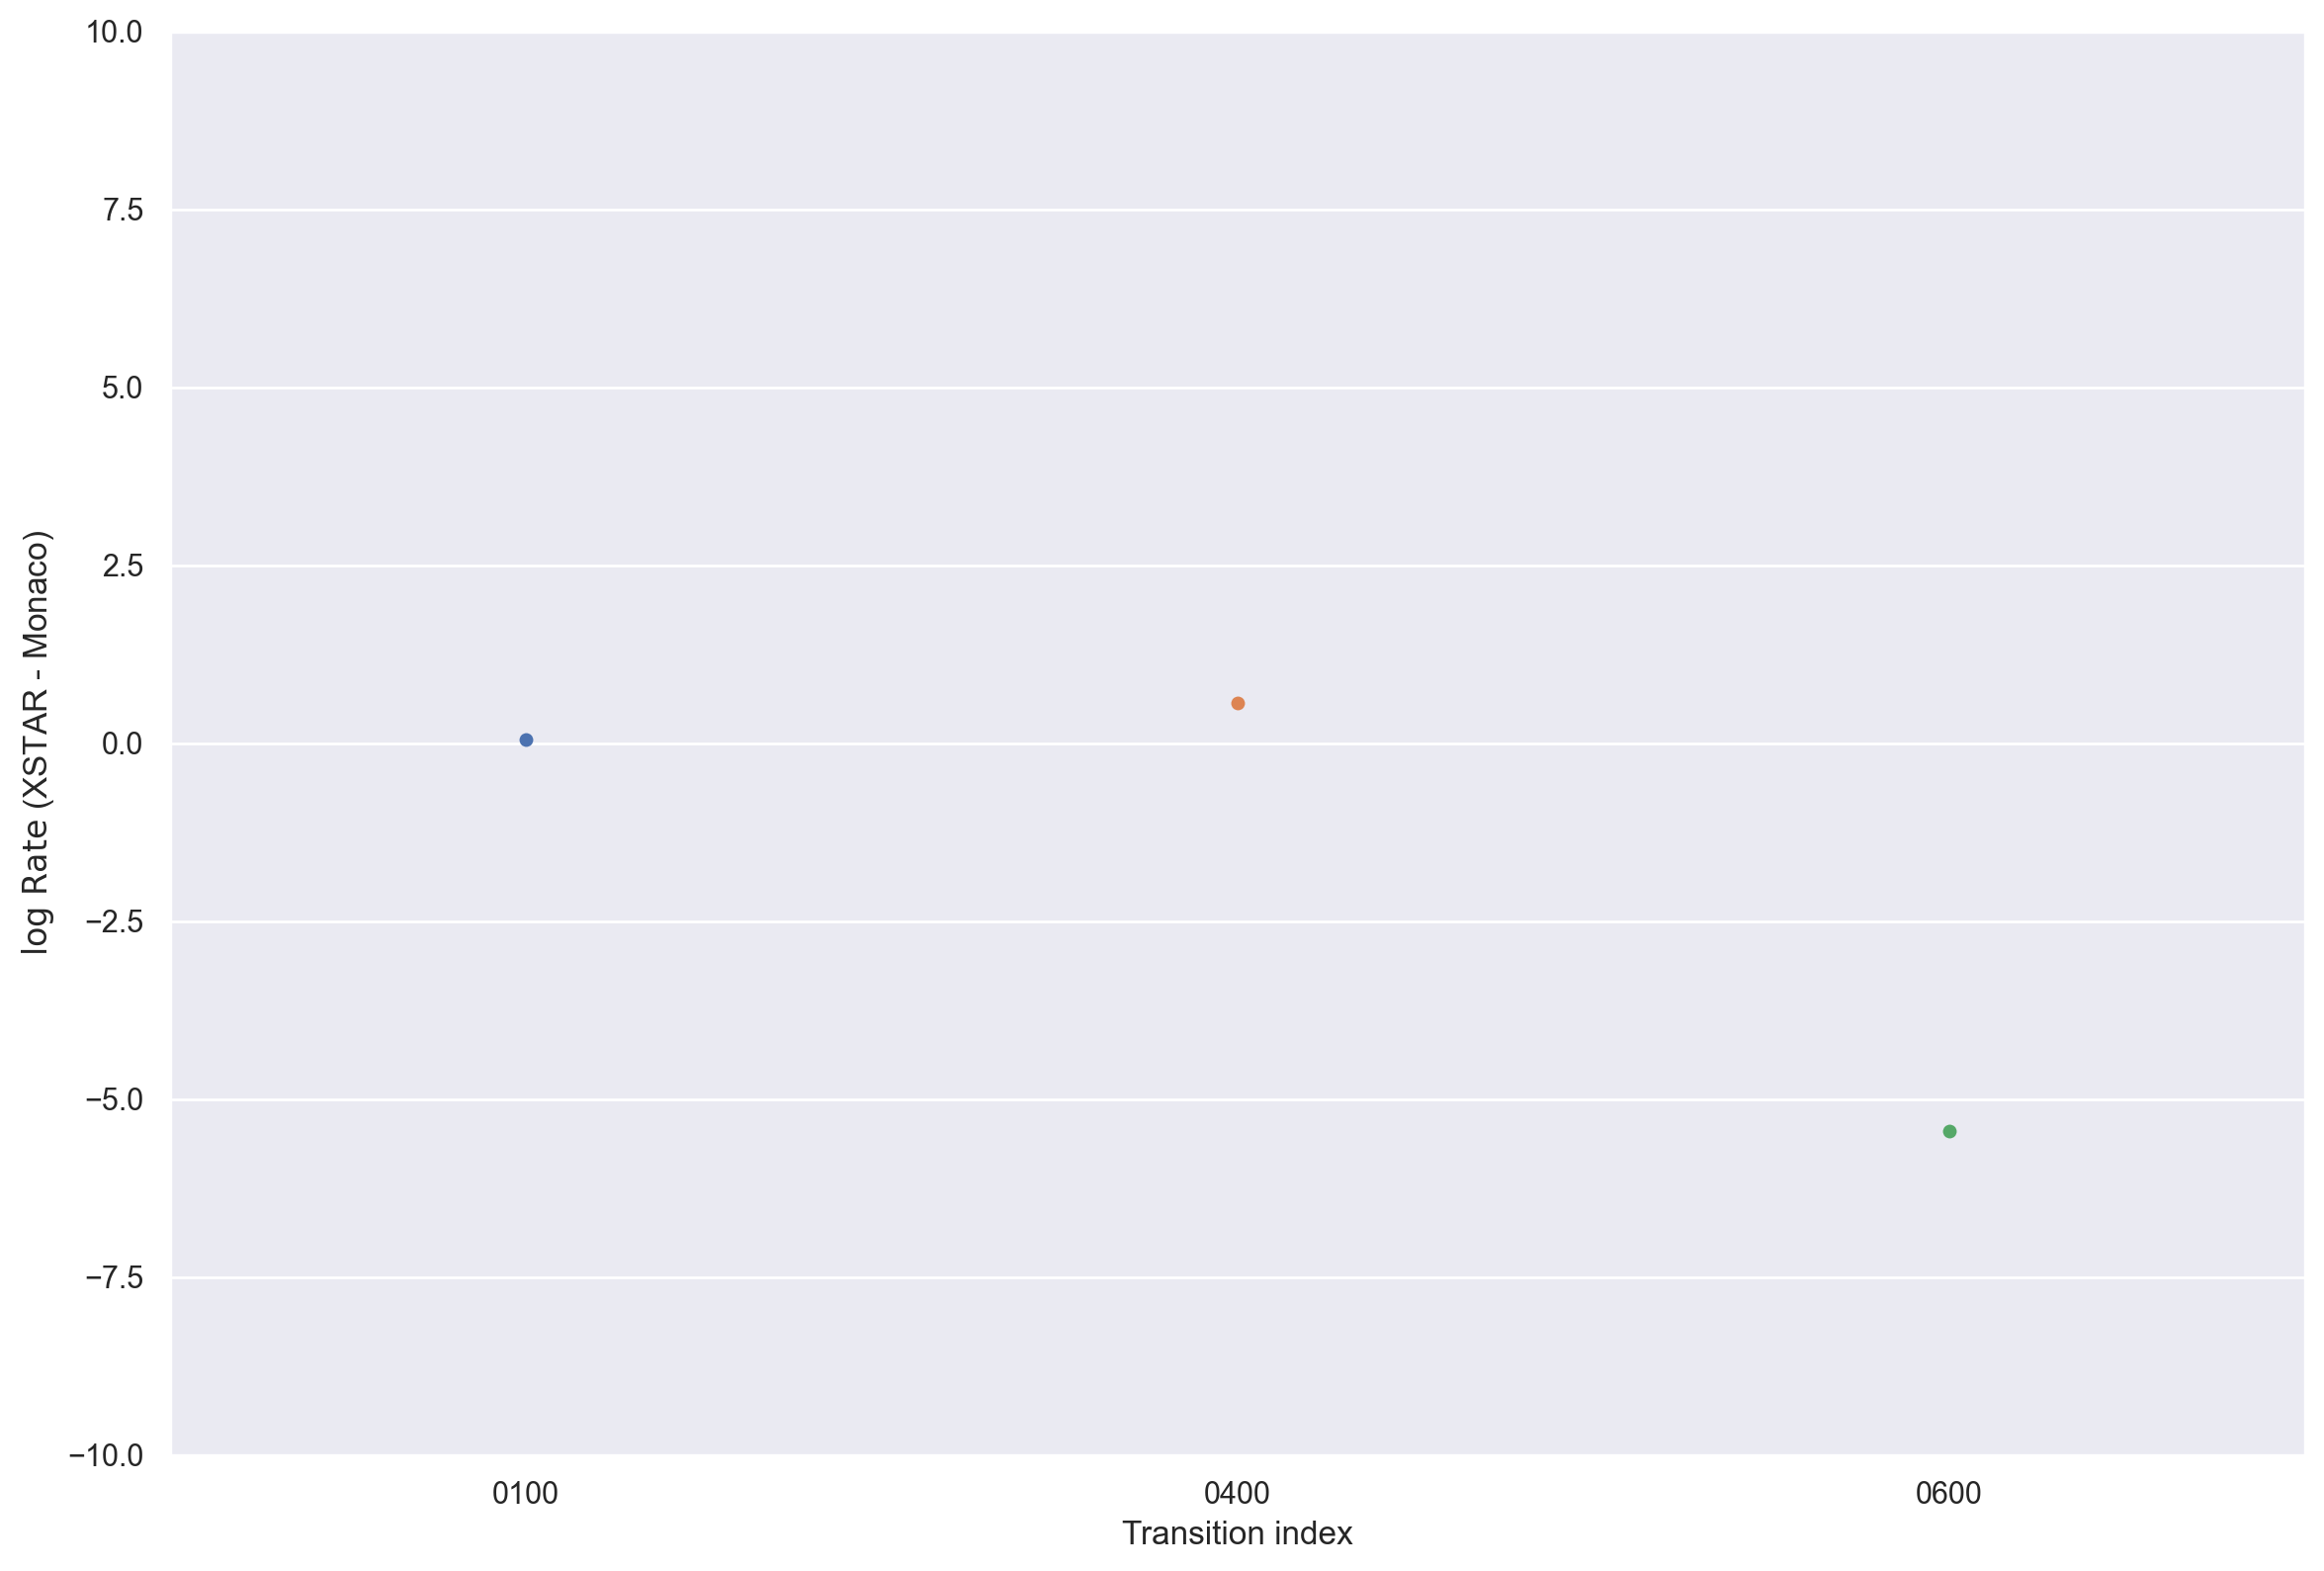

In [20]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si02_Transition_Index, y=Si02_Transition_Rate)
xlabel         ("Transition index")
ylabel         ("$\log \ \mathrm{Rate}$ (XSTAR - Monaco)")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/06.png")